# Notebook 07 — OAS Analysis: The Full Risk Decomposition

## Fixed Income From Scratch

**This is the culmination of everything built in Notebooks 01-06.**

The OAS pipeline:
1. **Curve Construction** (NB01) → Initial term structure → Drift calibration
2. **Volatility Surface** (NB05) → Factor volatilities → Path generation  
3. **Monte Carlo** (NB06) → Rate paths → Mortgage rate scenarios
4. **Prepayment Model** (NB03) → Path-specific CPRs from each rate scenario
5. **Cash Flow Engine** (NB02) → Path-specific cash flows
6. **Discounting** → Path PVs → Average → **OAS**

### OAS Definition:
The OAS is the constant spread $s$ added to the discount rates on every Monte Carlo path such that:

$$\frac{1}{N}\sum_{i=1}^{N}\sum_{t=1}^{T} CF_{i,t} \cdot e^{-\sum_{s=1}^{t}(r_{i,s} + OAS)\Delta t} = \text{Market Price}$$

### Risk Measures:
- **OA Duration/Convexity**: rate sensitivity including the prepayment option
- **ZOAS (Zero-Volatility OAS)**: OAS on the forward path only → **Option Cost = ZOAS - OAS**
- **Partial (Key-Rate) Duration**: exposure at specific curve tenors
- **Prepayment Duration**: sensitivity to prepayment model assumptions
- **Volatility Duration**: sensitivity to the vol surface level

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, os, time

sys.path.insert(0, os.path.abspath('..'))
from utils.curves import bootstrap_treasury_curve, bootstrap_swap_curve, sample_treasury_data, sample_swap_data
from utils.cashflows import MBSPool, project_mbs_cashflows
from utils.prepayment_model import PrepaymentTuning
from utils.monte_carlo import RateModelParams, SimulationConfig, simulate_rate_paths
from utils.oas import (
    run_full_oas_analysis, solve_oas, compute_zoas,
    compute_path_prices, compute_oa_duration_convexity,
    compute_partial_durations, compute_prepay_duration, OASResult
)
from utils.spreads import z_spread as compute_z_spread

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

# Build curves
tenors, par_yields = sample_treasury_data()
tsy_curve = bootstrap_treasury_curve(tenors, par_yields)
dep_t, dep_r, swp_t, swp_r = sample_swap_data()
swap_curve = bootstrap_swap_curve(dep_t, dep_r, swp_t, swp_r)

print("OAS analysis modules loaded. All 7 notebooks connected.")

OAS analysis modules loaded. All 7 notebooks connected.


---
## 1. Computing OAS — The Full Pipeline

Let's compute OAS for a FNMA 6.0% pass-through at various prices. For each price, we:
1. Generate Monte Carlo paths (once)
2. Solve for the OAS that equates average model price to market price
3. Compare to Z-spread (deterministic, single-scenario)

In [26]:
# Setup
pool = MBSPool(
    original_balance=1_000_000, current_balance=988_000,
    wac=0.065, net_coupon=0.060, wam=348, age=12, original_term=360
)
tuning = PrepaymentTuning()
params = RateModelParams()
config = SimulationConfig(num_paths=256, num_months=348, seed=42)

# Generate paths once
t0 = time.time()
paths = simulate_rate_paths(tsy_curve, params, config)
print(f"Path generation: {time.time()-t0:.1f}s ({paths.num_paths} paths)")

# Compute OAS at multiple prices
prices = [97.0, 99.0, 100.0, 101.0, 103.0, 105.0]
results = {}

print(f"\nComputing OAS across prices...")
for price in prices:
    t0 = time.time()
    oas = solve_oas(pool, paths, price, tuning)
    zoas = compute_zoas(pool, tsy_curve, price, tuning)
    elapsed = time.time() - t0
    
    # Also compute Z-spread at 150 PSA for comparison
    cf_150 = project_mbs_cashflows(pool, psa_speed=150)
    times_yr = cf_150.flows['month'].values / 12.0
    cfs = cf_150.flows['total_cashflow'].values
    mask = cfs > 0
    z_spr = compute_z_spread(price, times_yr[mask], cfs[mask], tsy_curve, face=pool.current_balance)
    
    results[price] = {
        'oas': oas * 10000 if not np.isnan(oas) else np.nan,
        'zoas': zoas * 10000 if not np.isnan(zoas) else np.nan,
        'option_cost': (zoas - oas) * 10000 if not (np.isnan(oas) or np.isnan(zoas)) else np.nan,
        'z_spread_150': z_spr * 10000 if not np.isnan(z_spr) else np.nan
    }
    print(f"  Price {price:6.1f}: OAS={results[price]['oas']:6.1f}bp, ZOAS={results[price]['zoas']:6.1f}bp, "
          f"OptCost={results[price]['option_cost']:5.1f}bp, Z@150PSA={results[price]['z_spread_150']:6.1f}bp  ({elapsed:.1f}s)")

Path generation: 0.0s (256 paths)

Computing OAS across prices...
  Price   97.0: OAS= 207.5bp, ZOAS= 236.6bp, OptCost= 29.1bp, Z@150PSA= 226.0bp  (7.8s)
  Price   99.0: OAS= 161.6bp, ZOAS= 194.2bp, OptCost= 32.7bp, Z@150PSA= 190.9bp  (7.7s)
  Price  100.0: OAS= 139.3bp, ZOAS= 173.7bp, OptCost= 34.4bp, Z@150PSA= 173.8bp  (7.5s)
  Price  101.0: OAS= 117.5bp, ZOAS= 153.6bp, OptCost= 36.0bp, Z@150PSA= 157.0bp  (7.5s)
  Price  103.0: OAS=  75.3bp, ZOAS= 114.4bp, OptCost= 39.2bp, Z@150PSA= 124.3bp  (7.5s)
  Price  105.0: OAS=  34.7bp, ZOAS=  76.8bp, OptCost= 42.1bp, Z@150PSA=  92.7bp  (7.4s)


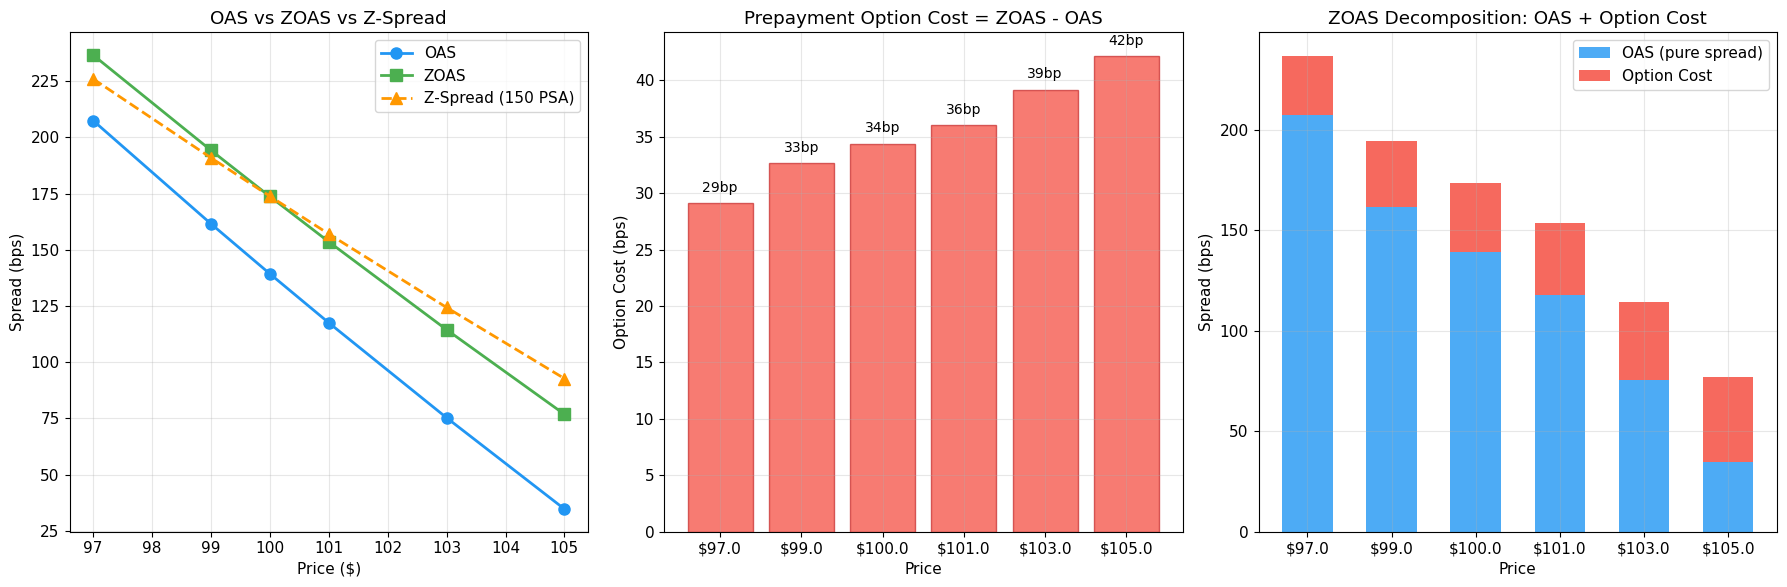

KEY RELATIONSHIPS:
  ZOAS = OAS + Option Cost  (always, by definition)
  Option Cost ≥ 0           (prepayment option has non-negative value)
  OAS < Z-Spread            (Z-spread includes option cost; OAS strips it out)
  OAS is the 'pure' spread  — compensation for credit, liquidity, and model risk


In [27]:
# Visualize OAS vs Z-spread
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

price_arr = list(results.keys())
oas_arr = [results[p]['oas'] for p in price_arr]
zoas_arr = [results[p]['zoas'] for p in price_arr]
opt_cost_arr = [results[p]['option_cost'] for p in price_arr]
z150_arr = [results[p]['z_spread_150'] for p in price_arr]

# OAS vs ZOAS vs Z-spread
ax = axes[0]
ax.plot(price_arr, oas_arr, 'o-', linewidth=2, markersize=8, label='OAS', color='#2196F3')
ax.plot(price_arr, zoas_arr, 's-', linewidth=2, markersize=8, label='ZOAS', color='#4CAF50')
ax.plot(price_arr, z150_arr, '^--', linewidth=2, markersize=8, label='Z-Spread (150 PSA)', color='#FF9800')
ax.set_xlabel('Price ($)')
ax.set_ylabel('Spread (bps)')
ax.set_title('OAS vs ZOAS vs Z-Spread')
ax.legend()

# Option cost
ax = axes[1]
ax.bar(range(len(price_arr)), opt_cost_arr, color='#F44336', alpha=0.7, edgecolor='#C62828')
ax.set_xticks(range(len(price_arr)))
ax.set_xticklabels([f'${p}' for p in price_arr])
ax.set_xlabel('Price')
ax.set_ylabel('Option Cost (bps)')
ax.set_title('Prepayment Option Cost = ZOAS - OAS')
for i, v in enumerate(opt_cost_arr):
    ax.text(i, v + 1, f'{v:.0f}bp', ha='center', fontsize=10)

# Decomposition
ax = axes[2]
x = range(len(price_arr))
width = 0.6
ax.bar(x, oas_arr, width, label='OAS (pure spread)', color='#2196F3', alpha=0.8)
ax.bar(x, opt_cost_arr, width, bottom=oas_arr, label='Option Cost', color='#F44336', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'${p}' for p in price_arr])
ax.set_xlabel('Price')
ax.set_ylabel('Spread (bps)')
ax.set_title('ZOAS Decomposition: OAS + Option Cost')
ax.legend()

plt.tight_layout()
plt.show()

print("KEY RELATIONSHIPS:")
print("  ZOAS = OAS + Option Cost  (always, by definition)")
print("  Option Cost ≥ 0           (prepayment option has non-negative value)")
print("  OAS < Z-Spread            (Z-spread includes option cost; OAS strips it out)")
print("  OAS is the 'pure' spread  — compensation for credit, liquidity, and model risk")

---
## 2. Full OAS Risk Report

Now we run the complete analysis with all risk measures. This is what a portfolio manager sees every morning — the comprehensive risk decomposition for each security.

In [29]:
# Run full OAS analysis with risk measures
print("Running full OAS analysis with risk decomposition...")
print("(This includes bump-and-reprice for duration, convexity, partial durations, etc.)")
print()

t0 = time.time()
full_result = run_full_oas_analysis(
    pool=pool, curve=tsy_curve, market_price=101.0,
    tuning=tuning, params=params,
    config=SimulationConfig(num_paths=256, num_months=348, seed=42),
    compute_risk=True
)
elapsed = time.time() - t0

print("=" * 60)
print("  COMPLETE OAS RISK REPORT")
print(f"  FNMA 6.0% Pass-Through | Price: 101.00")
print("=" * 60)
summary = full_result.summary_dict()
for key, val in summary.items():
    if isinstance(val, float):
        if 'bps' in key.lower() or 'cost' in key.lower():
            print(f"  {key:<30s} {val:>12.1f} bps")
        elif 'duration' in key.lower() or 'convexity' in key.lower():
            print(f"  {key:<30s} {val:>12.3f}")
        elif '%' in key:
            print(f"  {key:<30s} {val:>12.2f}%")
        elif 'wal' in key.lower():
            print(f"  {key:<30s} {val:>12.2f} years")
        elif 'error' in key.lower():
            print(f"  {key:<30s} {val:>12.4f}")
        else:
            print(f"  {key:<30s} {val:>12.3f}")
    elif isinstance(val, int):
        print(f"  {key:<30s} {val:>12d}")
print("=" * 60)
print(f"  Computation time: {elapsed:.1f}s")
print()
print("INTERPRETATION:")
print(f"  OAS ({full_result.oas_bps:.0f}bp) = pure spread compensation over the risk-free curve")
print(f"  Option Cost ({full_result.option_cost_bps:.0f}bp) = value of the prepayment option to the borrower")
print(f"  OA Duration ({full_result.oa_duration:.2f}) < Static Duration — prepayment option dampens rate sensitivity")
if full_result.oa_convexity < 0:
    print(f"  Negative Convexity ({full_result.oa_convexity:.1f}) — classic MBS feature: price upside is capped")

Running full OAS analysis with risk decomposition...
(This includes bump-and-reprice for duration, convexity, partial durations, etc.)

  COMPLETE OAS RISK REPORT
  FNMA 6.0% Pass-Through | Price: 101.00
  OAS (bps)                             117.5 bps
  ZOAS (bps)                            153.6 bps
  Option Cost (bps)                      36.0 bps
  OA Duration                           4.511
  OA Convexity                       -187.272
  Prepay Duration                       0.015
  Vol Duration                          0.018
  CC Duration                           0.000
  Avg WAL                                6.40 years
  Avg CPR (%)                           11.07%
  Num Paths                               256
  Price Std Error                      0.3312
  KRD 2Y                                0.190
  KRD 5Y                                0.785
  KRD 10Y                               1.632
  KRD 30Y                               0.075
  Computation time: 21.3s

INTERPRETATION

---
## 3. Key-Rate (Partial) Duration Profile

Partial durations show WHERE on the curve the security has exposure. For an MBS:
- Most exposure is in the **5-10Y** range (where mortgage duration sits)
- Short-end exposure exists because of the MBS amortization profile
- Sum of partial durations ≈ OA Duration

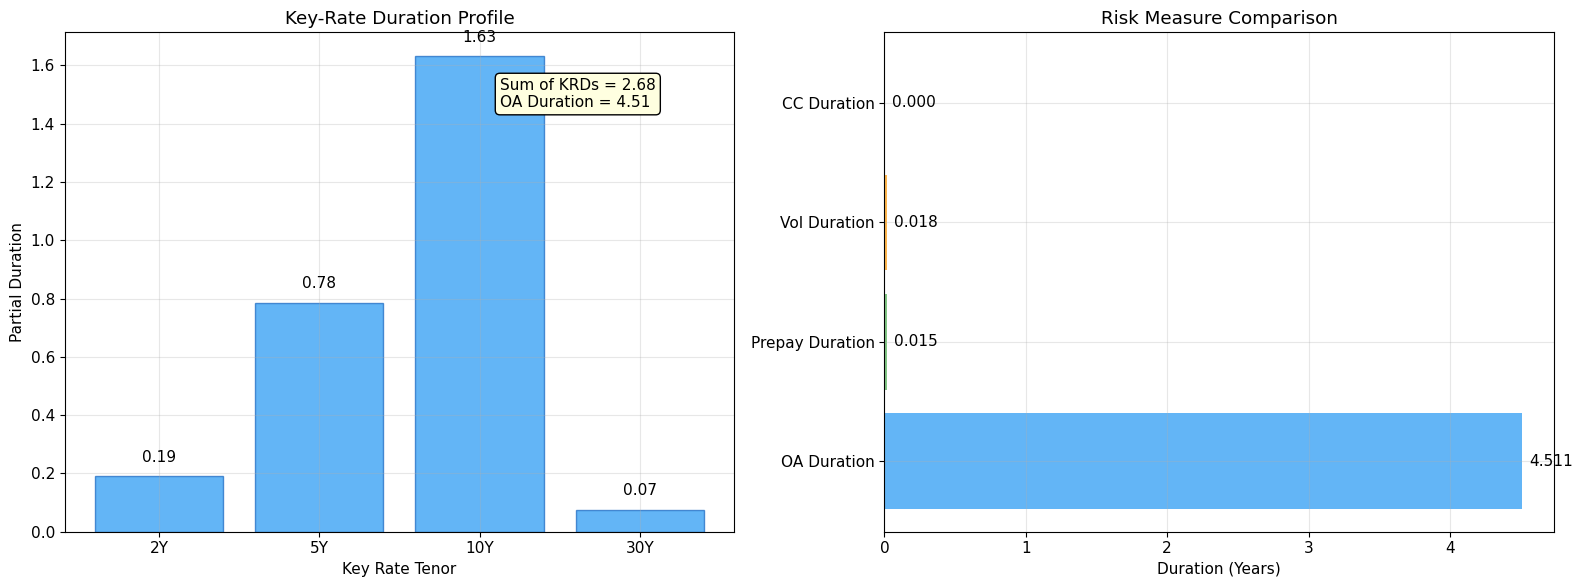

PARTIAL DURATION INTERPRETATION:
  2Y: 0.190 — a 1bp rise in the 2Y rate changes price by ~$19
  5Y: 0.785 — a 1bp rise in the 5Y rate changes price by ~$78
  10Y: 1.632 — a 1bp rise in the 10Y rate changes price by ~$161
  30Y: 0.075 — a 1bp rise in the 30Y rate changes price by ~$7


In [31]:
# Visualize partial durations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of partial durations
krd = full_result.partial_durations
kr_labels = list(krd.keys())
kr_values = list(krd.values())

ax1.bar(kr_labels, kr_values, color='#2196F3', alpha=0.7, edgecolor='#1565C0')
ax1.set_xlabel('Key Rate Tenor')
ax1.set_ylabel('Partial Duration')
ax1.set_title('Key-Rate Duration Profile')
ax1.axhline(y=0, color='black', linewidth=0.5)
for i, v in enumerate(kr_values):
    ax1.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=11)

sum_krd = sum(kr_values)
ax1.annotate(f'Sum of KRDs = {sum_krd:.2f}\nOA Duration = {full_result.oa_duration:.2f}',
             xy=(0.65, 0.85), xycoords='axes fraction', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Duration comparison: OAS vs Static
ax2.barh(['OA Duration', 'Prepay Duration', 'Vol Duration', 'CC Duration'],
         [full_result.oa_duration, full_result.prepay_duration, 
          full_result.vol_duration, full_result.current_coupon_duration],
         color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'], alpha=0.7)
ax2.set_xlabel('Duration (Years)')
ax2.set_title('Risk Measure Comparison')
for i, v in enumerate([full_result.oa_duration, full_result.prepay_duration,
                         full_result.vol_duration, full_result.current_coupon_duration]):
    ax2.text(max(v, 0) + 0.05, i, f'{v:.3f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

print("PARTIAL DURATION INTERPRETATION:")
for k, v in krd.items():
    print(f"  {k}: {v:.3f} — a 1bp rise in the {k} rate changes price by ~${abs(v)*0.01*pool.current_balance/100:,.0f}")

---
## 4. Relative Value — OAS Across Different Coupons

The real power of OAS: comparing securities with different coupons, WALs, and prepayment profiles on a common metric. A wider OAS means more compensation — either the market sees more risk, or the bond is cheap.

Relative Value Comparison — OAS Across Coupons
Security         Price      OAS     ZOAS  OptCost   AvgWAL   AvgCPR
-------------------------------------------------------------------------------------
FNMA 4.5%         95.0    67.1    78.1    11.0    10.2     6.8%
FNMA 5.0%         97.5    81.1   103.6    22.5     8.9     8.2%
FNMA 5.5%         99.0   106.8   137.5    30.7     7.5     9.8%
FNMA 6.0%        101.0   117.5   153.6    36.0     6.2    11.5%
FNMA 6.5%        103.0   117.7   141.3    23.6     5.1    13.2%
FNMA 7.0%        105.0   103.4   102.8    -0.6     4.3    14.7%


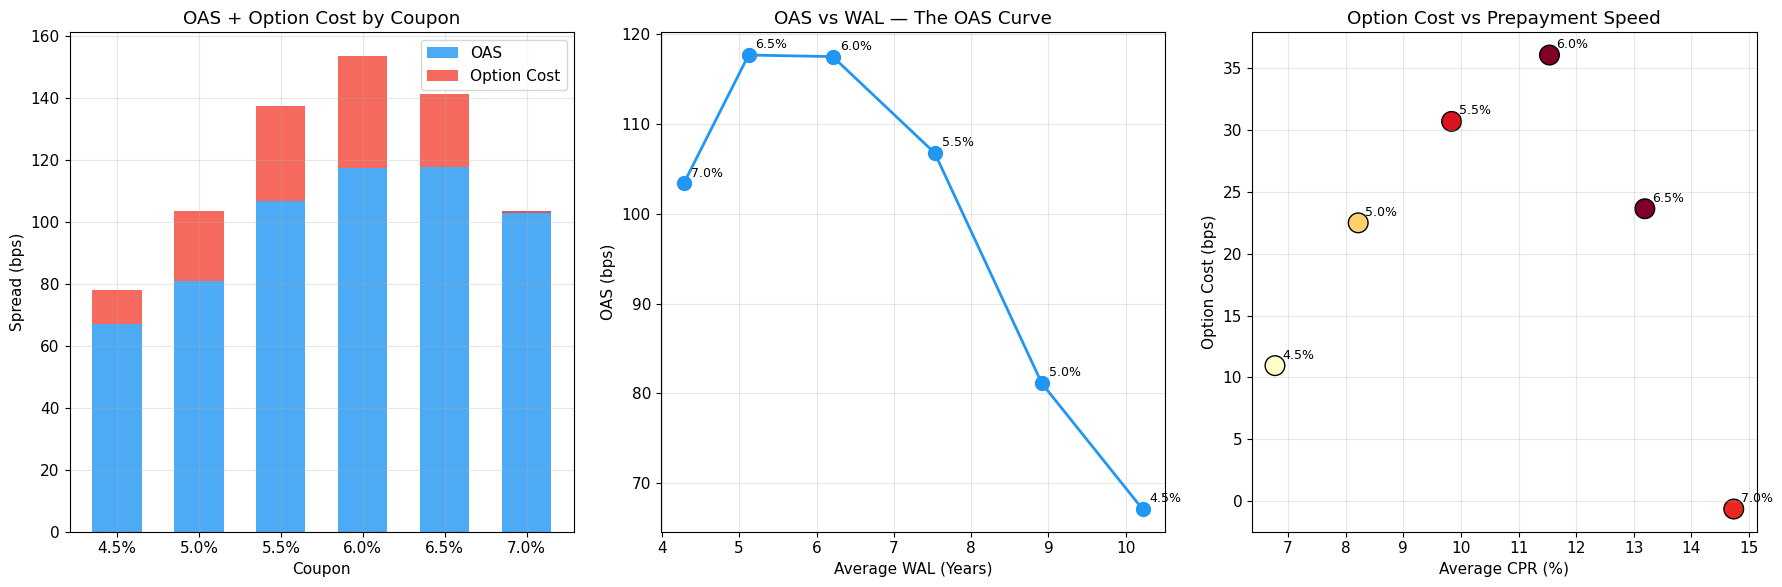


Higher coupons have higher option cost (more 'in the money' for refinancing).
OAS should be relatively stable across coupons for comparable securities.
Large OAS outliers suggest relative value opportunities.


In [33]:
# Compare OAS across different coupons
coupons_to_test = [
    ('FNMA 4.5%', 0.050, 0.045, 95.0),
    ('FNMA 5.0%', 0.055, 0.050, 97.5),
    ('FNMA 5.5%', 0.060, 0.055, 99.0),
    ('FNMA 6.0%', 0.065, 0.060, 101.0),
    ('FNMA 6.5%', 0.070, 0.065, 103.0),
    ('FNMA 7.0%', 0.075, 0.070, 105.0),
]

print("Relative Value Comparison — OAS Across Coupons")
print("=" * 85)
print(f"{'Security':<15} {'Price':>6} {'OAS':>8} {'ZOAS':>8} {'OptCost':>8} {'AvgWAL':>8} {'AvgCPR':>8}")
print("-" * 85)

from utils.prepayment_model import project_prepayment_rates
rv_results = []
for name, wac, net_cpn, price in coupons_to_test:
    p = MBSPool(1_000_000, 988_000, wac, net_cpn, 348, 12, 360)
    
    oas_val = solve_oas(p, paths, price, tuning)
    zoas_val = compute_zoas(p, tsy_curve, price, tuning)
    
    # Quick WAL/CPR estimate from a sample of paths
    sample_wals = []
    sample_cprs = []
    for i in range(50):
        mtg = paths.mortgage_rates[i, :348]
        pr = project_prepayment_rates(wac, mtg, 348, 12, 360, tuning=tuning)
        cf = project_mbs_cashflows(p, smm_vector=pr.total_smm)
        sample_wals.append(cf.weighted_avg_life)
        sample_cprs.append(np.mean(pr.total_cpr))
    
    
    oas_bps = oas_val * 10000 if not np.isnan(oas_val) else 0
    zoas_bps = zoas_val * 10000 if not np.isnan(zoas_val) else 0
    opt_cost = zoas_bps - oas_bps
    
    rv_results.append({
        'name': name, 'price': price, 'oas': oas_bps, 'zoas': zoas_bps,
        'opt_cost': opt_cost, 'wal': np.mean(sample_wals), 'cpr': np.mean(sample_cprs)
    })
    
    print(f"{name:<15} {price:>6.1f} {oas_bps:>7.1f} {zoas_bps:>7.1f} {opt_cost:>7.1f} "
          f"{np.mean(sample_wals):>7.1f} {np.mean(sample_cprs)*100:>7.1f}%")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

names = [r['name'] for r in rv_results]
oas_vals = [r['oas'] for r in rv_results]
opt_costs = [r['opt_cost'] for r in rv_results]
wals = [r['wal'] for r in rv_results]

ax = axes[0]
x = range(len(names))
ax.bar(x, oas_vals, width=0.6, label='OAS', color='#2196F3', alpha=0.8)
ax.bar(x, opt_costs, width=0.6, bottom=oas_vals, label='Option Cost', color='#F44336', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([n.split()[1] for n in names], rotation=0)
ax.set_xlabel('Coupon')
ax.set_ylabel('Spread (bps)')
ax.set_title('OAS + Option Cost by Coupon')
ax.legend()

ax = axes[1]
ax.plot([r['wal'] for r in rv_results], [r['oas'] for r in rv_results], 'o-', 
        linewidth=2, markersize=10, color='#2196F3')
for r in rv_results:
    ax.annotate(r['name'].split()[1], xy=(r['wal'], r['oas']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Average WAL (Years)')
ax.set_ylabel('OAS (bps)')
ax.set_title('OAS vs WAL — The OAS Curve')

ax = axes[2]
ax.scatter([r['cpr']*100 for r in rv_results], [r['opt_cost'] for r in rv_results],
           s=200, c=[r['oas'] for r in rv_results], cmap='YlOrRd', edgecolors='black', linewidth=1)
for r in rv_results:
    ax.annotate(r['name'].split()[1], xy=(r['cpr']*100, r['opt_cost']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set_xlabel('Average CPR (%)')
ax.set_ylabel('Option Cost (bps)')
ax.set_title('Option Cost vs Prepayment Speed')

plt.tight_layout()
plt.show()

print("\nHigher coupons have higher option cost (more 'in the money' for refinancing).")
print("OAS should be relatively stable across coupons for comparable securities.")
print("Large OAS outliers suggest relative value opportunities.")

---
## Summary — The Complete Pipeline

### What We Built Across 7 Notebooks:

| Notebook | Module | Purpose |
|:---------|:-------|:--------|
| 01 | Curve Construction | Treasury & swap zero curves, forward rates |
| 02 | MBS Cash Flows | Cash flow projection, Z-spread, nominal spread |
| 03 | Prepayment Model | 4-component model: refi, turnover, burnout, aging |
| 04 | CMO Structuring | Sequential, PAC/Companion, IO/PO waterfalls |
| 05 | Volatility Surfaces | Swaption vols, SABR calibration, Black model |
| 06 | Monte Carlo | 3-factor rate model, path generation, validation |
| 07 | **OAS Analysis** | **OAS, ZOAS, option cost, full risk decomposition** |

### The OAS Pipeline (everything connected):
```
Initial Curve → Drift Calibration ─┐
                                    ├→ Monte Carlo Paths ─┐
Vol Surface → Factor Volatilities ──┘                     │
                                                          ├→ Path PVs → Average → OAS
Pool Characteristics ──→ Cash Flow Engine ────────────────┘
                              ↑
Mortgage Rate Path → Prepayment Model → CPR Vector ──┘
```

### Key Results:
- **OAS** isolates pure spread compensation by properly accounting for the prepayment option
- **Option Cost = ZOAS - OAS** is always non-negative for prepayable securities
- **OA Duration** < Static Duration because prepayment option caps upside
- **Negative Convexity** is the defining risk characteristic of MBS
- **Partial durations** show most rate exposure in the 5-10Y sector
- **OAS comparison** across coupons enables true relative value analysis